<a href="https://colab.research.google.com/github/bru02/epstein/blob/main/notebooks/corpus_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corpus analysis

Run in Colab or locally. The first cell fetches data artifacts from GitHub when running on Colab.

In [1]:
is_colab = "google.colab" in str(get_ipython())
if is_colab:
    get_ipython().system("pip install -q uv")
    from pathlib import Path
    from urllib.request import urlretrieve
    root = "/content/epstein"
    base_url = "https://github.com/bru02/epstein/raw/main"
    Path(root, "data").mkdir(parents=True, exist_ok=True)
    for remote_path in [
        "pyproject.toml",
        "uv.lock",
        "data/fact_emails.parquet",
        "data/bridge_email_people.parquet",
        "data/dim_people.parquet",
    ]:
        target = Path(root, remote_path)
        target.parent.mkdir(parents=True, exist_ok=True)
        urlretrieve(f"{base_url}/{remote_path}", target)
        print(target, target.stat().st_size)
    get_ipython().magic("cd /content/epstein")
    get_ipython().system("uv sync --only-group corpus-analysis")

/content/epstein/pyproject.toml 916
/content/epstein/uv.lock 256396
/content/epstein/data/fact_emails.parquet 343937426
/content/epstein/data/bridge_email_people.parquet 24210272
/content/epstein/data/dim_people.parquet 100767
/content/epstein
Resolved 132 packages in 237ms
Checked 20 packages in 0.50ms


In [2]:
%matplotlib inline
from collections import Counter
import json
import math
from pathlib import Path
import re
from time import perf_counter

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

Path("outputs").mkdir(exist_ok=True)
started_at = perf_counter()
last_at = started_at
token_pattern = re.compile(r"\b[a-zA-Z][a-zA-Z']{2,}\b")
sentence_pattern = re.compile(r"[.!?]+")
stop_words = set(ENGLISH_STOP_WORDS)


def log(label):
    global last_at
    now = perf_counter()
    print(f"[analysis] {label}: phase={now - last_at:.2f}s total={now - started_at:.2f}s", flush=True)
    last_at = now


def write_frame(frame, path):
    frame.write_csv(Path("outputs") / path)
    print(f"[analysis] wrote outputs/{path}", flush=True)


def prune(counter, keep):
    if len(counter) <= keep * 2:
        return counter
    return Counter(dict(counter.most_common(keep)))


def tokenize(text):
    return [
        token
        for token in (match.group(0).lower() for match in token_pattern.finditer(text or ""))
        if token not in stop_words
    ]


def ngrams(tokens, size):
    return (" ".join(tokens[index : index + size]) for index in range(len(tokens) - size + 1))


def count_syllables(word):
    cleaned = re.sub(r"[^a-z]", "", word.lower())
    if not cleaned:
        return 0
    count = len(re.findall(r"[aeiouy]+", cleaned))
    if cleaned.endswith("e") and count > 1:
        count -= 1
    return max(1, count)


def text_metrics(text):
    raw_tokens = token_pattern.findall(text or "")
    sentences = [part for part in sentence_pattern.split(text or "") if part.strip()]
    if not raw_tokens or not sentences:
        return None
    syllables = sum(count_syllables(token) for token in raw_tokens)
    words = len(raw_tokens)
    sentence_count = len(sentences)
    types = len(set(token.lower() for token in raw_tokens))
    return {
        "tokens": words,
        "sentences": sentence_count,
        "types": types,
        "type_token_ratio": types / words,
        "flesch_reading_ease": 206.835 - 1.015 * (words / sentence_count) - 84.6 * (syllables / words),
        "flesch_kincaid_grade": 0.39 * (words / sentence_count) + 11.8 * (syllables / words) - 15.59,
    }


def plot_barh(labels, values, path, title, xlabel, color):
    plt.figure(figsize=(9, 7))
    plt.barh(labels, values, color=color)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(Path("outputs") / path, dpi=160)
    plt.show()


def compact_language_text(text):
    compact = re.sub(r"\s+", " ", text or "").strip()
    return compact.replace("\n", " ")


def load_language_model():
    try:
        import fasttext
        model_path = Path("models") / "lid.176.ftz"
        model_path.parent.mkdir(exist_ok=True)
        if not model_path.exists():
            import urllib.request
            urllib.request.urlretrieve(
                "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz",
                model_path,
            )
        return fasttext.load_model(str(model_path))
    except Exception as error:
        print(f"[analysis] fastText language detection unavailable: {error}", flush=True)
        return None


def fallback_language_indicator(text):
    compact = compact_language_text(text)
    if len(compact) < 80:
        return "too_short"
    raw_tokens = [match.group(0).lower() for match in token_pattern.finditer(compact[:1000])]
    if sum(1 for token in raw_tokens[:200] if token in stop_words) >= 3:
        return "likely_en"
    if compact.isascii():
        return "unknown_ascii"
    return "unknown_non_ascii"


def flush_language_batch(language_model, language_batch, language_counter, confidence_counter):
    if not language_batch:
        return
    labels, probabilities = language_model.predict(language_batch, k=1)
    for label_values, probability_values in zip(labels, probabilities):
        label = label_values[0].replace("__label__", "")
        language_counter[label] += 1
        confidence_counter[label] += float(probability_values[0])
    language_batch.clear()

## Load data

In [3]:
emails = pl.read_parquet("data/fact_emails.parquet")
bridge = pl.read_parquet("data/bridge_email_people.parquet")
people = pl.read_parquet("data/dim_people.parquet")
analysis_emails = emails.filter(
    pl.col("duplicate_id_flag").not_() & pl.col("duplicate_signature_flag").not_() & (pl.col("text_token_len") > 0)
)
valid_dated_emails = emails.filter(pl.col("year").is_not_null())
log("loaded parquet")

print(f"raw documents: {emails.height:,}")
print(f"analysis documents: {analysis_emails.height:,}")

[analysis] loaded parquet: phase=7.70s total=7.70s
raw documents: 1,758,382
analysis documents: 1,741,380


## Corpus statistics

[analysis] wrote outputs/corpus_summary.csv
[analysis] wrote outputs/metadata_missingness.csv


,metric,value
0,raw_documents,1758382
1,analysis_documents,1741380
2,average_document_tokens,66.70
3,median_document_tokens,28
4,average_document_characters,377.25
5,median_document_characters,151
6,empty_text_rows,17002
7,very_short_rows_under_10_tokens,364622
8,duplicate_id_rows,0
9,duplicate_signature_rows,0


,field,missing_rate,missing_pct
0,folder_path,0.996841,99.68
1,subject_base,0.486154,48.62
2,subject,0.309008,30.90
3,year,0.014938,1.49
4,body_clean,0.014050,1.40
5,text_clean,0.007300,0.73
6,sent_at,0.002826,0.28
7,email_id,0.000000,0.00
8,doc_id,0.000000,0.00
9,message_index,0.000000,0.00


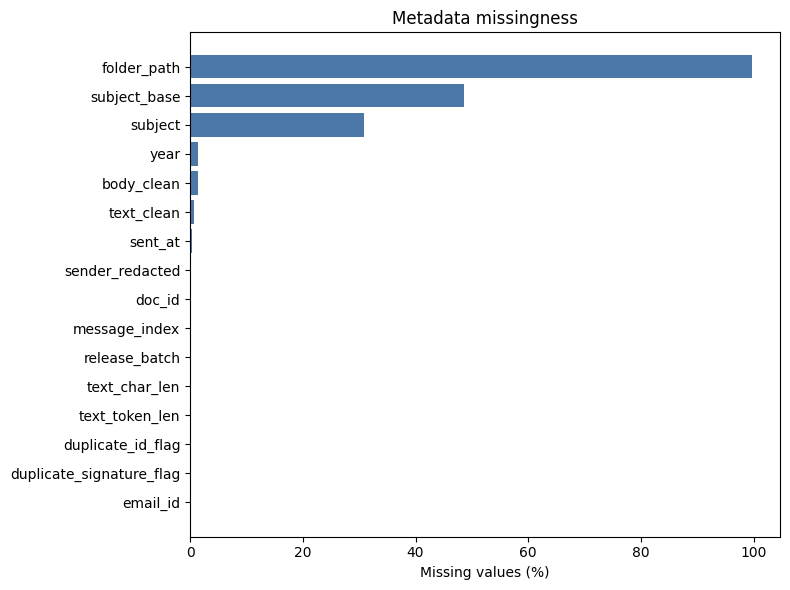

In [4]:
summary_rows = [
    ("raw_documents", f"{emails.height}"),
    ("analysis_documents", f"{analysis_emails.height}"),
    ("average_document_tokens", f"{float(emails.get_column('text_token_len').mean()):.2f}"),
    ("median_document_tokens", f"{float(emails.get_column('text_token_len').median()):.0f}"),
    ("average_document_characters", f"{float(emails.get_column('text_char_len').mean()):.2f}"),
    ("median_document_characters", f"{float(emails.get_column('text_char_len').median()):.0f}"),
    ("empty_text_rows", f"{emails.filter(pl.col('text_token_len') == 0).height}"),
    ("very_short_rows_under_10_tokens", f"{emails.filter(pl.col('text_token_len') < 10).height}"),
    ("duplicate_id_rows", f"{emails.filter(pl.col('duplicate_id_flag')).height}"),
    ("duplicate_signature_rows", f"{emails.filter(pl.col('duplicate_signature_flag')).height}"),
    ("sender_redacted_rows", f"{emails.filter(pl.col('sender_redacted')).height}"),
    ("raw_min_sent_at", f"{emails.get_column('sent_at').min()}"),
    ("raw_max_sent_at", f"{emails.get_column('sent_at').max()}"),
    ("valid_dated_rows_1990_2019", f"{valid_dated_emails.height}"),
    ("missing_or_out_of_range_date_rows", f"{emails.height - valid_dated_emails.height}"),
    ("min_valid_sent_at", f"{valid_dated_emails.get_column('sent_at').min()}"),
    ("max_valid_sent_at", f"{valid_dated_emails.get_column('sent_at').max()}"),
    ("distinct_valid_years", f"{valid_dated_emails.get_column('year').n_unique()}"),
    ("people_rows", f"{people.height}"),
    ("email_person_links", f"{bridge.height}"),
]
write_frame(pl.DataFrame(summary_rows, schema=["metric", "value"], orient="row"), "corpus_summary.csv")

missing_exprs = []
for column in emails.columns:
    expr = pl.col(column).is_null()
    if emails.schema[column] == pl.String:
        expr = expr | (pl.col(column).str.strip_chars() == "")
    missing_exprs.append(expr.mean().alias(column))
missingness = (
    emails.select(missing_exprs)
    .transpose(include_header=True, header_name="field", column_names=["missing_rate"])
    .with_columns((pl.col("missing_rate") * 100).round(2).alias("missing_pct"))
    .sort("missing_rate", descending=True)
)
write_frame(missingness, "metadata_missingness.csv")

display(pl.DataFrame(summary_rows, schema=["metric", "value"], orient="row").to_pandas())
display(missingness.to_pandas())

missing_plot = missingness.to_pandas().sort_values("missing_rate")
plt.figure(figsize=(8, 6))
plt.barh(missing_plot["field"], missing_plot["missing_pct"], color="#4c78a8")
plt.xlabel("Missing values (%)")
plt.title("Metadata missingness")
plt.tight_layout()
plt.savefig(Path("outputs") / "metadata_missingness.png", dpi=160)
plt.show()

## Date anomalies and time span

In [5]:
date_anomalies = (
    emails.filter(pl.col("sent_at").is_not_null() & pl.col("year").is_null())
    .select("email_id", "doc_id", "subject", "sent_at", "release_batch", "folder_path", "text_token_len")
    .sort("sent_at")
)
missing_sent_at_rows = emails.filter(pl.col("sent_at").is_null()).height
write_frame(
    pl.DataFrame(
        [
            ("missing_sent_at_rows", f"{missing_sent_at_rows}"),
            ("parsed_but_out_of_range_year_rows", f"{date_anomalies.height}"),
            ("missing_or_out_of_range_date_rows", f"{missing_sent_at_rows + date_anomalies.height}"),
            ("earliest_raw_sent_at", f"{emails.get_column('sent_at').min()}"),
            ("latest_raw_sent_at", f"{emails.get_column('sent_at').max()}"),
        ],
        schema=["metric", "value"],
        orient="row",
    ),
    "date_anomaly_summary.csv",
)
write_frame(date_anomalies.head(1000), "date_anomalies_sample.csv")

by_year = emails.group_by("year").agg(pl.len().alias("documents")).sort("year")
release_batch_coverage = emails.group_by("release_batch").agg(pl.len().alias("documents")).sort("release_batch")
write_frame(by_year, "documents_by_year.csv")
write_frame(release_batch_coverage, "release_batch_coverage.csv")
log("corpus metadata")

display(by_year.to_pandas())
display(release_batch_coverage.to_pandas())

[analysis] wrote outputs/date_anomaly_summary.csv
[analysis] wrote outputs/date_anomalies_sample.csv
[analysis] wrote outputs/documents_by_year.csv
[analysis] wrote outputs/release_batch_coverage.csv
[analysis] corpus metadata: phase=2.79s total=10.50s


,year,documents
0,NaN,26266
1,1990.0,621
2,1991.0,1502
3,1992.0,2
4,1993.0,3
5,1994.0,3
6,1995.0,1
7,1996.0,7
8,1997.0,7
9,1998.0,4


,release_batch,documents
0,1,13864
1,2,20
2,3,12
3,4,12
4,5,1
5,8,1057
6,9,629550
7,10,447162
8,11,666633
9,12,71


## Term frequencies, language detection, readability, and KWIC

Single-pass loop over all analysis documents. Computes unigram/bigram/trigram frequencies, language detection, readability metrics, and KWIC concordances.

In [6]:
term_tf = Counter()
term_df = Counter()
ngram_tf = Counter()
ngram_df = Counter()
readability_rows = []
language_counter = Counter()
language_confidence = Counter()
language_model = load_language_model()
language_batch = []
kwic_rows = {term: [] for term in ["island", "flight", "passport", "massage", "Maxwell"]}
kwic_patterns = {term: re.compile(re.escape(term), re.IGNORECASE) for term in kwic_rows}
doc_count = analysis_emails.height

for index, row in enumerate(
    analysis_emails.select("email_id", "sent_at", "subject", "text_clean").iter_rows(named=True),
    start=1,
):
    text = row["text_clean"] or ""
    tokens = tokenize(text)
    language_text = compact_language_text(text)
    if len(language_text) < 80:
        language_counter["too_short"] += 1
    elif language_model is None:
        language_counter[fallback_language_indicator(text)] += 1
    else:
        language_batch.append(language_text[:1000])
        if len(language_batch) >= 4096:
            flush_language_batch(language_model, language_batch, language_counter, language_confidence)
    unique_terms = set(tokens)
    term_tf.update(tokens)
    term_df.update(unique_terms)
    doc_ngrams = []
    if len(tokens) >= 2:
        doc_ngrams.extend(ngrams(tokens, 2))
    if len(tokens) >= 3:
        doc_ngrams.extend(ngrams(tokens, 3))
    ngram_tf.update(doc_ngrams)
    ngram_df.update(set(doc_ngrams))
    if len(tokens) >= 50:
        metrics = text_metrics(text)
        if metrics:
            readability_rows.append(metrics)
    for term, pattern in kwic_patterns.items():
        if len(kwic_rows[term]) >= 500:
            continue
        for match in pattern.finditer(text):
            kwic_rows[term].append(
                {
                    "email_id": row["email_id"],
                    "sent_at": row["sent_at"],
                    "subject": row["subject"],
                    "left": text[max(0, match.start() - 80) : match.start()].replace("\n", " "),
                    "keyword": text[match.start() : match.end()],
                    "right": text[match.end() : match.end() + 80].replace("\n", " "),
                }
            )
            if len(kwic_rows[term]) >= 500:
                break
    if index % 100_000 == 0:
        term_tf = prune(term_tf, 300_000)
        term_df = Counter({term: term_df[term] for term in term_tf})
        ngram_tf = prune(ngram_tf, 500_000)
        ngram_df = Counter({term: ngram_df[term] for term in ngram_tf})
        print(f"[analysis] counted {index:,}", flush=True)

if language_model is not None:
    flush_language_batch(language_model, language_batch, language_counter, language_confidence)
log("language indicators, readability, terms, n-grams, kwic")

[analysis] fastText language detection unavailable: No module named 'fasttext'
[analysis] counted 100,000
[analysis] counted 200,000
[analysis] counted 300,000
[analysis] counted 400,000
[analysis] counted 500,000
[analysis] counted 600,000
[analysis] counted 700,000
[analysis] counted 800,000
[analysis] counted 900,000
[analysis] counted 1,000,000
[analysis] counted 1,100,000
[analysis] counted 1,200,000
[analysis] counted 1,300,000
[analysis] counted 1,400,000
[analysis] counted 1,500,000
[analysis] counted 1,600,000
[analysis] counted 1,700,000
[analysis] language indicators, readability, terms, n-grams, kwic: phase=1143.22s total=1153.72s


## Language distribution

In [7]:
language_distribution = (
    pl.DataFrame(
        [
            (
                language,
                documents,
                None if language_confidence[language] == 0 else round(language_confidence[language] / documents, 4),
            )
            for language, documents in language_counter.items()
        ],
        schema=["language", "documents", "avg_confidence"],
        orient="row",
    )
    .with_columns((pl.col("documents") / pl.col("documents").sum() * 100).round(2).alias("pct"))
    .sort("documents", descending=True)
)
write_frame(language_distribution, "language_distribution.csv")
display(language_distribution.to_pandas())

[analysis] wrote outputs/language_distribution.csv


,language,documents,avg_confidence,pct
0,likely_en,1119069,None,64.26
1,too_short,534329,None,30.68
2,unknown_ascii,78235,None,4.49
3,unknown_non_ascii,9747,None,0.56


## Term and n-gram frequencies

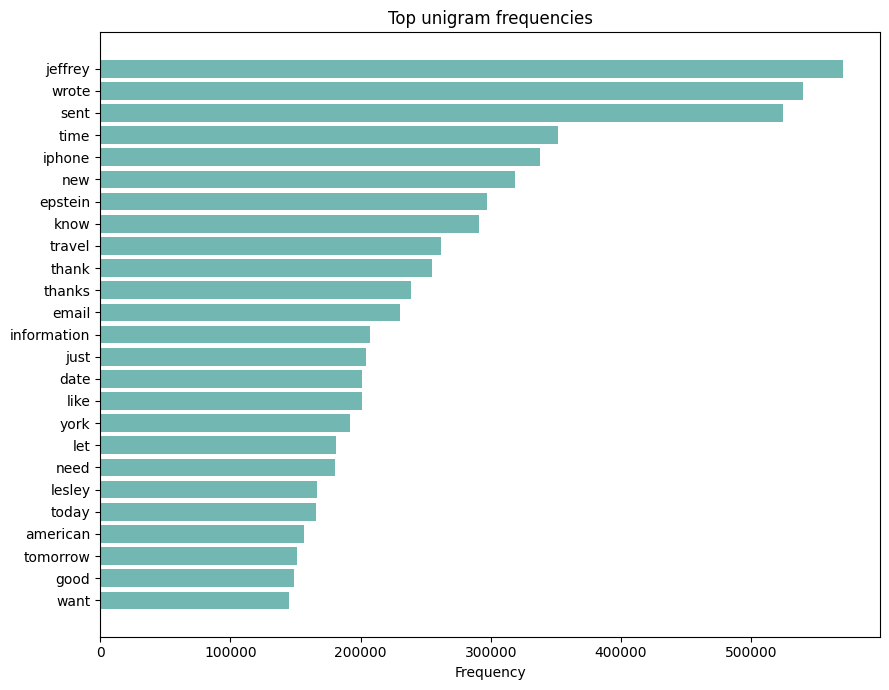

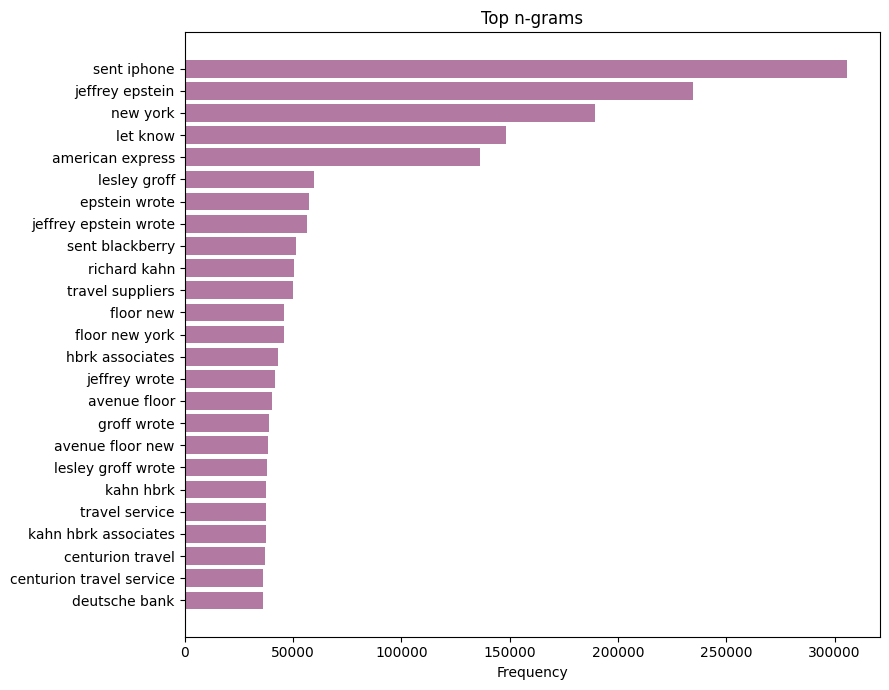

[analysis] term and n-gram outputs: phase=3.79s total=1157.51s


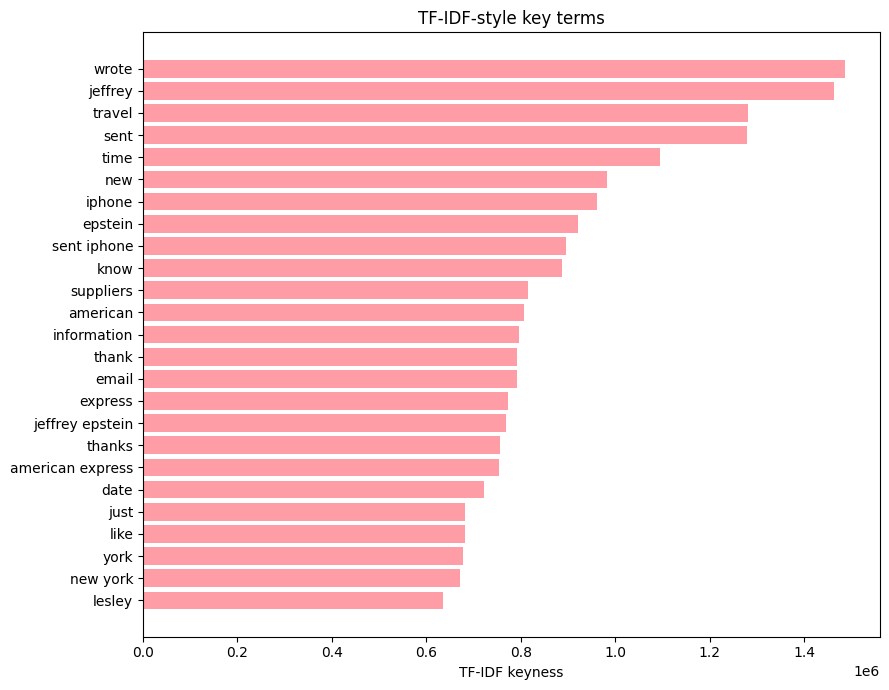

[analysis] tf-idf-style keyness: phase=1.95s total=1159.46s


In [8]:
term_rows = [
    {
        "term": term,
        "frequency": frequency,
        "document_frequency": term_df[term],
        "document_frequency_pct": term_df[term] / doc_count * 100,
    }
    for term, frequency in term_tf.most_common(100_000)
]
term_frequency_table = pd.DataFrame(term_rows)
term_frequency_table.to_csv(Path("outputs") / "term_frequencies.csv", index=False)
top_terms = term_frequency_table.head(25).iloc[::-1]
plot_barh(top_terms["term"], top_terms["frequency"], "top_terms.png", "Top unigram frequencies", "Frequency", "#72b7b2")

ngram_rows = [
    {
        "ngram": term,
        "frequency": frequency,
        "document_frequency": ngram_df[term],
        "document_frequency_pct": ngram_df[term] / doc_count * 100,
    }
    for term, frequency in ngram_tf.most_common(100_000)
]
ngram_table = pd.DataFrame(ngram_rows)
ngram_table.to_csv(Path("outputs") / "ngrams.csv", index=False)
top_ngrams = ngram_table.head(25).iloc[::-1]
plot_barh(top_ngrams["ngram"], top_ngrams["frequency"], "top_ngrams.png", "Top n-grams", "Frequency", "#b279a2")
log("term and n-gram outputs")

tfidf_rows = []
for row in term_rows:
    score = row["frequency"] * (1 + math.log((1 + doc_count) / (1 + row["document_frequency"])))
    tfidf_rows.append({"term": row["term"], "tfidf_keyness": score, "frequency": row["frequency"], "document_frequency": row["document_frequency"]})
for row in ngram_rows:
    score = row["frequency"] * (1 + math.log((1 + doc_count) / (1 + row["document_frequency"])))
    tfidf_rows.append({"term": row["ngram"], "tfidf_keyness": score, "frequency": row["frequency"], "document_frequency": row["document_frequency"]})
tfidf_table = pd.DataFrame(tfidf_rows).sort_values("tfidf_keyness", ascending=False).reset_index(drop=True)
tfidf_table.to_csv(Path("outputs") / "tfidf_key_terms.csv", index=False)
top_tfidf = tfidf_table.head(25).iloc[::-1]
plot_barh(top_tfidf["term"], top_tfidf["tfidf_keyness"], "top_tfidf_terms.png", "TF-IDF-style key terms", "TF-IDF keyness", "#ff9da6")
log("tf-idf-style keyness")

## KWIC concordances

In [9]:
for term, rows in kwic_rows.items():
    pl.DataFrame(rows).write_csv(Path("outputs") / f"kwic_{term.lower()}.csv")
    print(f"kwic_{term.lower()}: {len(rows)} rows")
log("kwic")

kwic_island: 500 rows
kwic_flight: 500 rows
kwic_passport: 500 rows
kwic_massage: 500 rows
kwic_maxwell: 500 rows
[analysis] kwic: phase=0.04s total=1159.50s


## Readability and lexical diversity

,tokens,sentences,types,type_token_ratio,flesch_reading_ease,flesch_kincaid_grade
count,233675.000000,233675.000000,233675.000000,233675.000000,233675.000000,233675.000000
mean,217.687973,19.127207,125.721712,0.663869,53.595462,8.881770
std,350.519338,27.061803,127.447006,0.117998,21.690584,4.660586
min,50.000000,1.000000,1.000000,0.004545,-546.619933,-3.404105
10%,78.000000,6.000000,57.000000,0.505495,22.690995,4.294000
25%,94.000000,9.000000,68.000000,0.589286,40.190150,5.854000
50%,128.000000,13.000000,88.000000,0.676471,56.389706,8.166667
75%,213.000000,22.000000,133.000000,0.748201,69.954577,10.982555
90%,472.000000,36.000000,251.000000,0.804878,78.905152,14.338755
max,26711.000000,4447.000000,4811.000000,1.000000,121.230684,238.806988


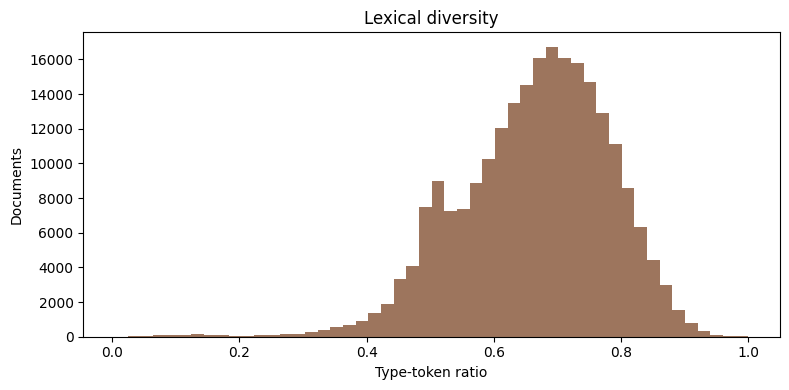

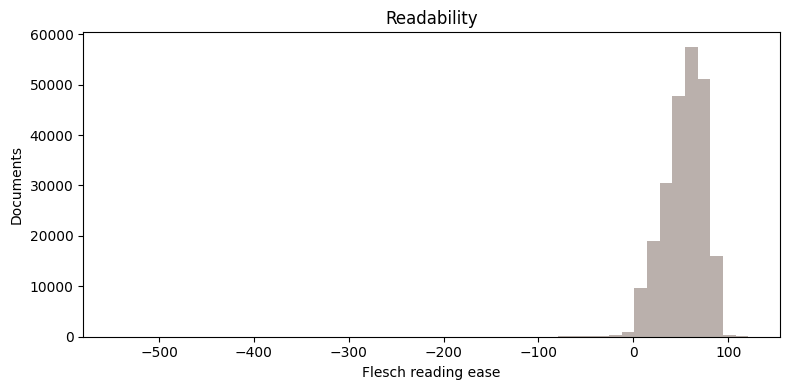

[analysis] readability: phase=3.24s total=1162.74s


In [10]:
readability_table = pd.DataFrame(readability_rows)
display(readability_table.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
readability_table.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_csv(Path("outputs") / "readability_lexical_summary.csv")
readability_table.sample(n=min(100_000, len(readability_table)), random_state=7).to_csv(
    Path("outputs") / "readability_lexical_sample.csv", index=False
)

plt.figure(figsize=(8, 4))
plt.hist(readability_table["type_token_ratio"], bins=50, color="#9d755d")
plt.xlabel("Type-token ratio")
plt.ylabel("Documents")
plt.title("Lexical diversity")
plt.tight_layout()
plt.savefig(Path("outputs") / "lexical_diversity.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(readability_table["flesch_reading_ease"], bins=50, color="#bab0ac")
plt.xlabel("Flesch reading ease")
plt.ylabel("Documents")
plt.title("Readability")
plt.tight_layout()
plt.savefig(Path("outputs") / "readability.png", dpi=160)
plt.show()
log("readability")

## People network

[analysis] wrote outputs/top_people.csv
[analysis] wrote outputs/involvement_role_counts.csv
[analysis] wrote outputs/people_coverage.csv


,metric,value
0,documents_with_people,1469644
1,analysis_documents,1741380
2,documents_with_people_pct,84.40


,involvement_role,links,documents
0,sender,1160681,1160681
1,to,908884,854017
2,cc,152900,102496
3,account_email,15037,15037
4,bcc,947,896


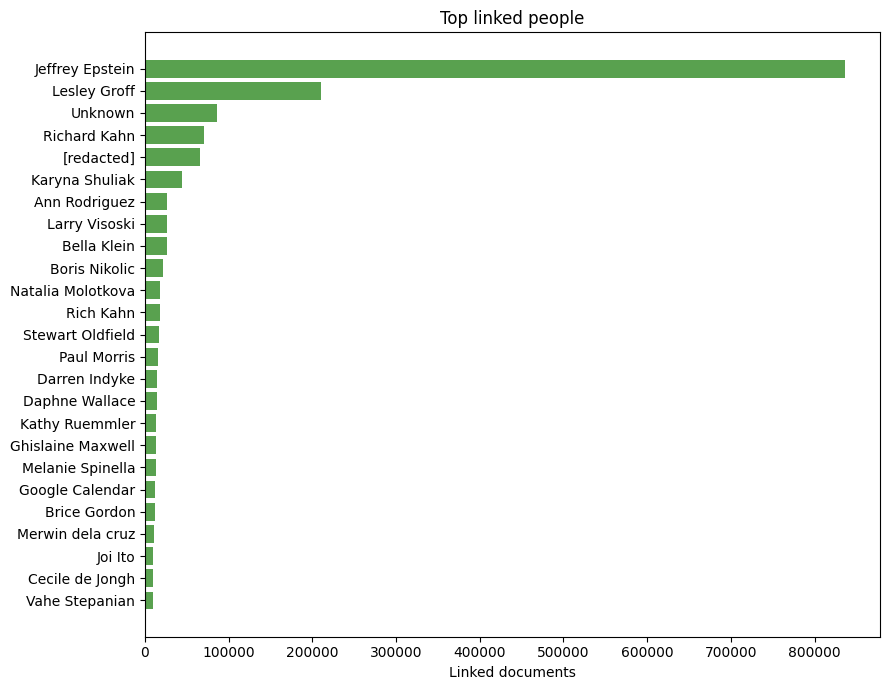

[analysis] people: phase=2.30s total=1165.04s


In [11]:
top_people = (
    bridge.group_by("person_id", "person_name")
    .agg(pl.col("email_id").n_unique().alias("documents"), pl.len().alias("links"))
    .sort("documents", descending=True)
    .head(100)
)
role_counts = (
    bridge.group_by("involvement_role")
    .agg(pl.len().alias("links"), pl.col("email_id").n_unique().alias("documents"))
    .sort("links", descending=True)
)
linked_document_count = bridge.select(pl.col("email_id").n_unique()).item()
people_coverage = pl.DataFrame(
    [
        ("documents_with_people", f"{linked_document_count}"),
        ("analysis_documents", f"{analysis_emails.height}"),
        ("documents_with_people_pct", f"{linked_document_count / analysis_emails.height * 100:.2f}"),
    ],
    schema=["metric", "value"],
    orient="row",
)
write_frame(top_people, "top_people.csv")
write_frame(role_counts, "involvement_role_counts.csv")
write_frame(people_coverage, "people_coverage.csv")

display(people_coverage.to_pandas())
display(role_counts.to_pandas())

top_people_plot = top_people.to_pandas().head(25).iloc[::-1]
plot_barh(top_people_plot["person_name"], top_people_plot["documents"], "top_people.png", "Top linked people", "Linked documents", "#59a14f")
log("people")

## Run metadata

In [12]:
metadata = {
    "documents_processed": doc_count,
    "term_counter_rows": len(term_rows),
    "ngram_counter_rows": len(ngram_rows),
    "keyness_method": "full-corpus frequency times smoothed inverse document frequency over retained top term and n-gram counters",
    "language_detection": "fastText lid.176.ftz when fasttext is installed; fallback buckets otherwise",
    "runtime_seconds": round(perf_counter() - started_at, 2),
}
(Path("outputs") / "run_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
print(json.dumps(metadata, indent=2))

{
  "documents_processed": 1741380,
  "term_counter_rows": 100000,
  "ngram_counter_rows": 100000,
  "keyness_method": "full-corpus frequency times smoothed inverse document frequency over retained top term and n-gram counters",
  "language_detection": "fastText lid.176.ftz when fasttext is installed; fallback buckets otherwise",
  "runtime_seconds": 1165.06
}
